# Coding Session 03 · Lab W3

## Today's plan

- Compute an assignment effect as grouped means and an OLS coefficient.
- Follow a randomization-inference scaffold and interpret its limits.
- Compare pre-treatment subgroups; retain NY recoding as additional practice.



In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


## From geographic tables to an experiment

The existing course file is the Kling and Stratmann partisan robocall experiment: one row is a registered voter, `group` is assignment to no calls, one, three, or six calls, and `voted` records turnout. `treatment` means assignment to any call arm, not confirmed receipt. `gen2012`, `age`, `income`, `male`, and `svh` are pre-treatment covariates. `svh` marks single-voter households.

Source: Kling and Stratmann (2023), [Large-Scale Evidence for the Effectiveness of Partisan GOTV Robo Calls](https://doi.org/10.1017/XPS.2022.16), using the course's existing extract.

**What this file can teach:** assignment contrasts, code for randomization inference, and subgroup summaries. It has no household or randomization-block identifiers. The permutation examples below therefore use an explicitly simplified model of individual complete random assignment; they are not a replication of the paper's design or publication-level uncertainty. Do not interpret turnout as persuasion, successful contact, or net votes for a candidate.


In [2]:
from pathlib import Path

# Works from a session folder, the repository root, or a fresh Colab notebook.
data_candidates = [
    Path("data/kling_stratmann_subset.csv"),
    Path("wk09_cost_effectiveness/data/kling_stratmann_subset.csv"),
    Path("../wk09_cost_effectiveness/data/kling_stratmann_subset.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
data_url = "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/wk09_cost_effectiveness/data/kling_stratmann_subset.csv"
calls = pd.read_csv(data_path if data_path is not None else data_url)
calls.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
2,64.0,75000.0,1.0,0,0,0,Control (No Call),0
3,63.0,75000.0,0.0,0,0,0,Control (No Call),0
4,21.0,100000.0,0.0,0,0,0,Control (No Call),0


## An effect as two means

Check assignments and missing outcomes before computing the estimate. The contrast below compares assignment to any call arm with control, averaging over the observed mix of call intensities. The estimate is a difference in turnout proportions; multiply by 100 for percentage points. A balance table describes observed pre-treatment similarity; it cannot prove that assignment was implemented correctly.


In [3]:
print(calls.groupby("treatment")["voted"].agg(rows="size", observed="count"))
assert calls["voted"].isin([0, 1]).all()
assert calls["treatment"].isin([0, 1]).all()
print(calls.groupby("treatment")[["gen2012", "age", "svh"]].mean())
turnout = calls.groupby("treatment")["voted"].mean()
assignment_effect = turnout.loc[1] - turnout.loc[0]
print("Assignment effect, percentage points:", 100 * assignment_effect)


             rows  observed
treatment                  
0          135331    135331
1          404236    404236
            gen2012        age       svh
treatment                               
0          0.766521  49.900291  0.101529
1          0.771525  49.983769  0.101696
Assignment effect, percentage points: 0.3160378255424423


### The same estimate in a regression

With an intercept and only a binary assignment indicator, OLS returns exactly the same group-mean difference. The intercept is the control mean. This algebra is also true in observational data; the assignment design supplies the causal interpretation. Adding pre-treatment covariates changes the specification, so its coefficient need not be exactly equal.


In [4]:
model = smf.ols("voted ~ treatment", data=calls).fit()
print(model.params)
assert np.isclose(model.params["treatment"], assignment_effect)
# A supplied extension: compare coefficients, not whether either is magically unbiased.
adjusted = smf.ols("voted ~ treatment + gen2012", data=calls).fit()
print("Adjusted assignment coefficient:", adjusted.params["treatment"])


Intercept    0.488639
treatment    0.003160
dtype: float64


Adjusted assignment coefficient: 0.0008250149534941498


## Randomization inference: follow the scaffold

Select 2,000 rows per assignment category without looking at turnout. This makes the teaching calculation manageable and changes the sample; report its own estimate. Under the **sharp null of no effect for every sampled voter**, hold outcomes fixed and shuffle assignment labels, preserving the two group sizes. Detaching labels with `.to_numpy()` prevents pandas from aligning them back to the original index.

The individual-assignment model is a teaching simplification for this extract. With full design information, shuffle whole assignment units within their original randomization blocks instead.


In [5]:
ri_sample = pd.concat([
    calls.loc[calls["treatment"] == arm].sample(n=2000, random_state=310 + arm)
    for arm in [0, 1]
]).reset_index(drop=True)
outcomes = ri_sample["voted"].to_numpy()
labels = ri_sample["treatment"].to_numpy()
observed_ri = outcomes[labels == 1].mean() - outcomes[labels == 0].mean()
rng = np.random.default_rng(310)
shuffled = rng.permutation(labels)
one_fake_gap = outcomes[shuffled == 1].mean() - outcomes[shuffled == 0].mean()
print("Sample observed gap / one shuffled gap:", observed_ri, one_fake_gap)


Sample observed gap / one shuffled gap: 0.014499999999999957 0.005500000000000005


Two-sided teaching-model p-value: 0.369


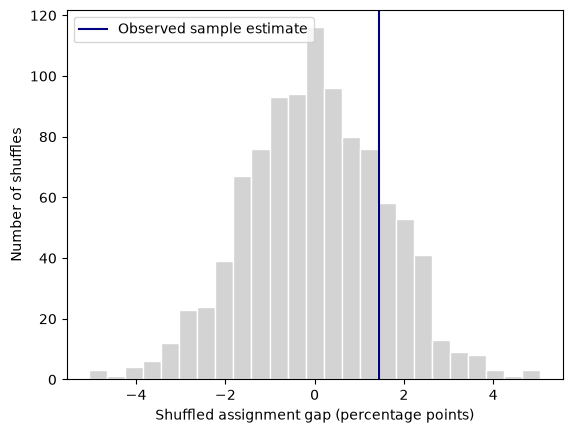

In [6]:
# Supplied scaffold: read the shuffle, comparison, and storage in order.
null_gaps = []
for repetition in range(999):
    shuffled = rng.permutation(labels)
    fake_gap = outcomes[shuffled == 1].mean() - outcomes[shuffled == 0].mean()
    null_gaps.append(fake_gap)
null_gaps = np.asarray(null_gaps)
p_value = (1 + np.count_nonzero(np.abs(null_gaps) >= abs(observed_ri))) / (1 + len(null_gaps))
print("Two-sided teaching-model p-value:", p_value)
plt.hist(100 * null_gaps, bins=25, color="lightgray", edgecolor="white")
plt.axvline(100 * observed_ri, color="navy", label="Observed sample estimate")
plt.xlabel("Shuffled assignment gap (percentage points)")
plt.ylabel("Number of shuffles")
plt.legend()
plt.show()


The p-value describes how unusual this statistic is under the stated null and assignment model. It is not the probability that the null is true. More shuffles reduce Monte Carlo noise; they do not fix an incorrect assignment model or missing identifiers.

## Subgroups: filter, group, and explain

We use pre-treatment vote history, not a characteristic affected by the calls. Each row compares treatment and control within a subgroup. A difference between subgroup estimates is not evidence that changing someone's past vote history would change the effect.


In [7]:
subgroups = calls.groupby(["gen2012", "treatment"])["voted"].mean().unstack("treatment")
subgroups = subgroups.rename(columns={0: "control", 1: "assigned_calls"})
subgroups["effect_pp"] = 100 * (subgroups["assigned_calls"] - subgroups["control"])
subgroups


treatment,control,assigned_calls,effect_pp
gen2012,,,
0,0.128177,0.132658,0.448098
1,0.598434,0.598154,-0.028069


**Practice — write the code:** filter to `svh == 1`, compute both assignment-group means and their difference, and express the answer in percentage points. Check each group's row count. This practices the lab's filter-and-estimate task with an available pre-treatment subgroup.

**Additional practice:** change the RI seed and explain why the p-value changes slightly. Compare subgroup effects and identify what uncertainty or design information you would need before claiming one subgroup benefits more. Explain why our robocall setting does not establish generalizability to the lab's mailer or another election.


In [8]:
# Your code: filter to single-voter households and compute the assignment contrast.


## Additional practice and reference: NY geographic data

Retained data-reading and recoding examples follow. One NY row is a Census Block, not an individual experimental voter. A mean of block shares weights blocks equally; a ratio of totals weights their included voter counts. Neither is an experimental effect. The denominator below includes only the three party categories supplied, not every registration category.


### 0. Environment preparation

We begin by loading the libraries we’ll need. In Python, libraries are like toolkits: they extend the language with specialized functions.

- **pandas (pd)** is our main tool for working with tabular data. It introduces the DataFrame, which lets us manipulate datasets in a way that feels natural if you’ve used Excel or R.
- **NumPy (np)** provides the numerical backbone. It gives us arrays and fast mathematical functions, which pandas actually uses under the hood.

----

### 1. Reading Datasets

This dataset was produced by the Redistricting Data Hub (RDH) using a voter file purchased from L2, a national voter file vendor, on March 9, 2021. The RDH retrieved and processed the data on April 16, 2021.

The original L2 voter file contains individual-level voter records. RDH aggregated these records to the 2010 Census Block level, identified by a GEOID constructed by concatenating County FIPS, Census Tract, and Census Block codes. In this way they were able to ceate counts for categorical variables such as party registration, gender, and modeled commercial data (e.g., likelihood of being a homeowner or magazine subscriptions).

To have a sense of what a Census Block is, you can take a look at this pdf of the [NYC Census Tracts Map](https://www.nyc.gov/assets/planning/download/pdf/about/publications/maps/nyc-census-tracts-map.pdf)



#### Codebook

This table describes the variables included in the dataset. The daset that we use in this coding session is a subset of the original dataset and can be accessesed via [Redistricting Data Hub](https://redistrictingdatahub.org/)

| Variable description |
| :--- |
| `party_dem`: Count of voters registered with the Democratic Party (L2 Voter File). Modeled: No. |
| `party_npp`: Count of voters registered with the Non-Partisan Party (L2 Voter File). Modeled: No. |
| `party_rep`: Count of voters registered with the Republican Party (L2 Voter File). Modeled: No. |
| `voters_gender_m`: Count of male voters. Modeled: No. |
| `voters_gender_f`: Count of female voters. Modeled: No. |
| `voters_gender_unknkown`: Count of voters with unknown or other gender. Modeled: No. |
| `commercialdatall_gun_owner`: Number of voters in Census Block who own guns based on gun registrations and subscriptions to gun/hunting magazines. Modeled: No. |
| `commercialdatall_home_owner_or_renter_likely_homeowner`: Count of voters likely to be homeowners. Modeled: Modeled. |
| `commercialdatall_home_owner_or_renter_likely_renter`: Count of voters likely to be renters. Modeled: Modeled. |
| `commercialdata_upscalebuyerinhome_avg`: Average number of upscale buyers in the home. Modeled: Modeled. |
| `commercialdata_familymagazineinhome_avg`: Average number of family magazines in the home. Modeled: Modeled. |
| `commercialdata_femaleorientedmagazineinhome_avg`: Average number of female-oriented magazines in the home. Modeled: Modeled. |
| `commercialdata_financialmagazineinhome_avg`: Average number of financial magazines in the home. Modeled: Modeled. |
| `commercialdata_gardeningmagazineinhome_avg`: Average number of gardening magazines in the home. Modeled: Modeled. |
| `commercialdata_healthfitnessmagazineinhome_avg`: Average number of health and fitness magazines in the home. Modeled: Modeled. |







#### 1.1 Load the data

Data usually comes as files (CSV, Excel, SQL, JSON, …). We tell pandas to read a CSV into a DataFrame with `pd.read_csv()`.

In Google Colab, we can load this course dataset directly from its online location.



In [9]:
from pathlib import Path

# Works from a session folder, the repository root, or a fresh Colab notebook.
data_candidates = [
    Path("data/nyvoterfile_2021.csv"),
    Path("wk03_rcts_and_ate/data/nyvoterfile_2021.csv"),
    Path("../wk03_rcts_and_ate/data/nyvoterfile_2021.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
data_url = "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/wk03_rcts_and_ate/data/nyvoterfile_2021.csv"
df_voterfile = pd.read_csv(data_path if data_path is not None else data_url)
df_voterfile.head()


,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,commercialdata_upscalebuyerinhome_avg,commercialdata_familymagazineinhome_avg,commercialdata_femaleorientedmagazineinhome_avg,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg
0,360593009005012,15,42,15,39,37,0,4,45,18,NaN,2.0,1.0,1.0,NaN,2.0
1,360710117023032,1,0,2,0,3,0,2,1,0,NaN,NaN,NaN,NaN,NaN,3.0
2,360550129004023,16,11,2,13,17,0,2,21,3,NaN,1.0,NaN,1.0,1.0,2.0
3,360271000001013,0,1,2,2,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
4,360359706003096,1,0,4,3,2,0,0,2,1,NaN,NaN,NaN,NaN,1.0,2.0


#### 1.2 Orient yourself

When you load a dataset, your first job is orient yourself:

- How many rows/columns are there? (`.shape`)
- What are the column names? (`.columns`)
- What kind of data is in each column (numbers, text, dates)? (`.dtypes`)

These commands are like "peeking inside the box" before doing any analysis.

The attribute `df.shape` tells you the **dimensions of your DataFrame**.  
It returns a tuple `(rows, columns)`:

- The first number = how many rows (observations).  
- The second number = how many columns (variables).  

In [10]:
df_voterfile.shape

(238827, 16)

The attribute `df.columns` returns the **names of all the columns** in your DataFrame.  


In [11]:
df_voterfile.columns

Index(['geoid', 'party_dem', 'party_npp', 'party_rep', 'voters_gender_m',
       'voters_gender_f', 'voters_gender_unknkown',
       'commercialdatall_gun_owner',
       'commercialdatall_home_owner_or_renter_likely_homeowner',
       'commercialdatall_home_owner_or_renter_likely_renter',
       'commercialdata_upscalebuyerinhome_avg',
       'commercialdata_familymagazineinhome_avg',
       'commercialdata_femaleorientedmagazineinhome_avg',
       'commercialdata_financialmagazineinhome_avg',
       'commercialdata_gardeningmagazineinhome_avg',
       'commercialdata_healthfitnessmagazineinhome_avg'],
      dtype='str')

The attribute `df.dtypes` shows the **data type** (`dtype`) of each column in your DataFrame.  

Common pandas dtypes include:  
- **int64** → whole numbers (e.g., counts, IDs)  
- **float64** → decimal numbers (e.g., percentages, continuous values)  
- **object** → text or mixed values (e.g., names, categories)  
- **bool** → True/False values  
- **datetime64** → dates and times  

In [12]:
df_voterfile.dtypes

geoid                                                       int64
party_dem                                                   int64
party_npp                                                   int64
party_rep                                                   int64
voters_gender_m                                             int64
voters_gender_f                                             int64
voters_gender_unknkown                                      int64
commercialdatall_gun_owner                                  int64
commercialdatall_home_owner_or_renter_likely_homeowner      int64
commercialdatall_home_owner_or_renter_likely_renter         int64
commercialdata_upscalebuyerinhome_avg                     float64
commercialdata_familymagazineinhome_avg                   float64
commercialdata_femaleorientedmagazineinhome_avg           float64
commercialdata_financialmagazineinhome_avg                float64
commercialdata_gardeningmagazineinhome_avg                float64
commercial

When you run `df.info()` in pandas, it gives you a **summary of your DataFrame**.  
This is useful for quickly checking the structure of your dataset.

In [13]:
df_voterfile.info()

<class 'pandas.DataFrame'>
RangeIndex: 238827 entries, 0 to 238826
Data columns (total 16 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   geoid                                                   238827 non-null  int64  
 1   party_dem                                               238827 non-null  int64  
 2   party_npp                                               238827 non-null  int64  
 3   party_rep                                               238827 non-null  int64  
 4   voters_gender_m                                         238827 non-null  int64  
 5   voters_gender_f                                         238827 non-null  int64  
 6   voters_gender_unknkown                                  238827 non-null  int64  
 7   commercialdatall_gun_owner                              238827 non-null  int64  
 8   commercialdatall_home_owner_or_rent

The command `df.describe()` gives you **descriptive statistics** for all the numeric columns in your DataFrame.  
It’s a quick way to understand the basic properties of your data.

In [14]:
df_voterfile.describe()

,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,commercialdata_upscalebuyerinhome_avg,commercialdata_familymagazineinhome_avg,commercialdata_femaleorientedmagazineinhome_avg,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg
count,2.388270e+05,238827.000000,238827.000000,238827.000000,238827.000000,238827.000000,238827.000000,238827.000000,238827.000000,238827.000000,43435.000000,170774.000000,91168.000000,125473.000000,98915.000000,186736.000000
mean,3.606577e+14,26.217090,11.739950,11.404431,23.984931,28.222709,0.012834,4.623167,18.046712,25.524296,1.369909,1.279240,1.085436,1.715086,1.495668,1.928086
std,3.392303e+11,68.368182,20.185044,17.355414,43.292107,56.266427,0.125702,7.407542,28.036967,85.899537,0.748987,0.615762,0.312860,1.134872,0.805553,1.104086
min,3.600100e+14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.604195e+14,2.000000,2.000000,2.000000,4.000000,4.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,3.606503e+14,8.000000,6.000000,6.000000,12.000000,13.000000,0.000000,2.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
75%,3.609574e+14,22.000000,14.000000,14.000000,26.000000,29.000000,0.000000,6.000000,23.000000,14.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000
max,3.612315e+14,2781.000000,1165.000000,848.000000,1886.000000,2252.000000,5.000000,285.000000,1052.000000,3025.000000,7.000000,9.000000,5.000000,9.000000,8.000000,9.000000


----

### 2. Recoding variables and if statements

#### 2.1 Math opertations with pandas

In pandas, you can do math directly on columns. Here we are adding together three columns — `party_dem`, `party_rep`, and `party_npp` — to create a new variable called **`total_voters`**.

In [15]:
total_voters = df_voterfile["party_dem"] + df_voterfile["party_rep"] + df_voterfile["party_npp"]
total_voters.head()

0    72
1     3
2    29
3     3
4     5
dtype: int64

Once we have the **total number of voters** in each row, we can calculate what share (percentage) belongs to each party. We do this by dividing the count of each party by the total:

In [16]:
valid_total = total_voters.where(total_voters > 0)
pct_dem = df_voterfile["party_dem"] / valid_total
pct_rep = df_voterfile["party_rep"] / valid_total
pct_npp = df_voterfile["party_npp"] / valid_total


We can calculate the **average share of each party** across all geoids. To do this, we use NumPy’s `np.mean()` function, which computes the mean of a Series or array.


In [17]:
avg_dem = np.mean(pct_dem)
avg_rep = np.mean(pct_rep)
avg_npp = np.mean(pct_npp)

print("Average Democratic Reg. share:", avg_dem)
print("Average Republican Reg. share:", avg_rep)
print("Average Non-partisan Reg. share:", avg_npp)

Average Democratic Reg. share: 0.40400820150761546
Average Republican Reg. share: 0.33789985753069646
Average Non-partisan Reg. share: 0.258091940961688


#### 2.2 Recoding with `np.where` (if statement)

We can use `np.where()` to create a new variable that marks rows where the proportion of non-partisan voters is **above a threshold** (for example, 0.8 = 80%).

In [18]:
df_voterfile["high_npp"] = pd.Series(
    np.where(pct_npp > 0.8, 1, 0), index=df_voterfile.index, dtype="Int64"
)
# An undefined share is missing, not a known low share.
df_voterfile.loc[pct_npp.isna(), "high_npp"] = pd.NA


- pct_npp > 0.8: This is the condition. It checks, for each row, whether the proportion of non-partisan voters (pct_npp) is greater than 0.8 (that is, 80%). The result is a column of True or False values.
- np.where(condition, 1, 0): np.where() replaces True with 1 and False with 0.
Among rows with a defined denominator, every row that meets the condition gets a 1 (high non-partisan area), otherwise a 0. We then use `pd.NA` for undefined shares so they are not counted as known low-share blocks.

#### 2.3 Freqency table



Let's now use value_counts() to create a simple frequency table

In [19]:
df_voterfile["high_npp"].value_counts()

high_npp
0    232970
1      4809
Name: count, dtype: Int64

We can also normalise the count and have percentage instead of absolute counts

In [20]:
# Percentages in %
df_voterfile["high_npp"].value_counts(normalize=True) * 100

high_npp
0    97.977534
1     2.022466
Name: proportion, dtype: Float64

Now that we have the column `high_npp` (1 = very high, 0 = not high), we can filter the DataFrame to only keep the rows where `high_npp` equals **1**.



In [21]:
df_high_npp = df_voterfile[df_voterfile["high_npp"] == 1]
df_high_npp.head()

,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,commercialdata_upscalebuyerinhome_avg,commercialdata_familymagazineinhome_avg,commercialdata_femaleorientedmagazineinhome_avg,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg,high_npp
312,361150820021068,0,1,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
335,360650256001007,0,1,0,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
363,360750206001036,0,1,0,0,1,0,0,1,0,NaN,NaN,NaN,NaN,1.0,2.0,1
387,360593035006009,0,2,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
395,360830409003028,0,1,0,1,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1


#### 2.4 Subsetting a dataframe (using geoid)

Let’s now zoom into one of these small geographical areas with a high share of non-partisan voters. Doing so will give us a more concrete sense of the data we are working with and how these identifiers connect to real places.

For instance, we can select the row where the GEOID equals 361031697013036. To do this, we filter the DataFrame by that condition:

In [22]:
# Filter for one specific GEOID using base pandas
geoid_row = df_voterfile[df_voterfile["geoid"] == 361031697013036]
# Show the result
geoid_row

,geoid,party_dem,party_npp,party_rep,voters_gender_m,voters_gender_f,voters_gender_unknkown,commercialdatall_gun_owner,commercialdatall_home_owner_or_renter_likely_homeowner,commercialdatall_home_owner_or_renter_likely_renter,commercialdata_upscalebuyerinhome_avg,commercialdata_familymagazineinhome_avg,commercialdata_femaleorientedmagazineinhome_avg,commercialdata_financialmagazineinhome_avg,commercialdata_gardeningmagazineinhome_avg,commercialdata_healthfitnessmagazineinhome_avg,high_npp
2349,361031697013036,0,2,0,1,2,0,0,2,0,NaN,1.0,NaN,NaN,NaN,NaN,1


The GEOID identifies a **2010 Census Block** in this extract. If exploring a map, select the matching geographic vintage; a 2020 block layer need not identify the same area.


----
### 3. Exercise: more complex if statements

We want to create a new column called `majority_party` that tells us which group has the **largest share of voters** in each row: Democrats, Republicans, or Non-partisans.

You can use np.where to accomplish this. Since you want to assign values based on multiple conditions, you’ll need to nest several np.where statements. Each np.where works like an if…else check: it evaluates a condition, assigns a value if the condition is true, and otherwise falls back to another option. By nesting them, you can chain together multiple if…elif…else rules. To do this correctly, you’ll also have to combine logical operators (like &) when writing your conditions


In [23]:
# Nested np.where(s)
df_voterfile["majority_party"] = np.where(
    (pct_dem > pct_rep) & (pct_dem > pct_npp), "Dem",
    np.where(
        (pct_rep > pct_dem) & (pct_rep > pct_npp), "Rep",
        np.where(
            (pct_npp > pct_dem) & (pct_npp > pct_rep), "NPP",
            "Tie"
        )
    )
)

df_voterfile.loc[valid_total.isna(), "majority_party"] = "Undefined: no included voters"

# Inspect after handling undefined denominators.
df_voterfile["majority_party"].value_counts(normalize=True)


majority_party
Dem                              0.454308
Rep                              0.340100
NPP                              0.110783
Tie                              0.090421
Undefined: no included voters    0.004388
Name: proportion, dtype: float64

1. **First condition:**  
   `(pct_dem > pct_rep) & (pct_dem > pct_npp)`  
   - This checks if the Democratic share is **bigger than both Republican and Non-partisan shares**.  
   - If true: label the row `"Dem"`.  

2. **Second condition:**  
   `(pct_rep > pct_dem) & (pct_rep > pct_npp)`  
   - Only runs if the first condition was false.  
   - Checks if Republicans have the largest share.  
   - If true: label the row `"Rep"`.  

3. **Third condition:**  
   `(pct_npp > pct_dem) & (pct_npp > pct_rep)`  
   - Runs if both earlier conditions were false.  
   - Checks if Non-partisans have the largest share.  
   - If true: label the row `"NPP"`.  

4. **Default (else):**  
   `"Tie"`  
   - If none of the conditions are true (e.g., two or more groups have the same max value), we assign `"Tie"`.  
